### Figure Reconstructions. 

#### Figure 6

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root
from scipy.optimize import brentq

In [14]:
beta = np.pi/2
alpha = .01
alpha_0 = .03
a = .3
eta = 5e-3
c = 9.65
d =.05
kappa = .09

def A(q):
    return a * (np.sqrt(q**2 + eta**2) - eta)

def eps0(q, Re):
    return (c / Re) * q


def u_nullcline(q, Re):
    return 1 - beta*A(q)/(alpha + beta**2/Re)


def q_equation(q, u, Re):
    return 0.5*beta*u*A(q) - 2*alpha*q - eps0(q, Re)


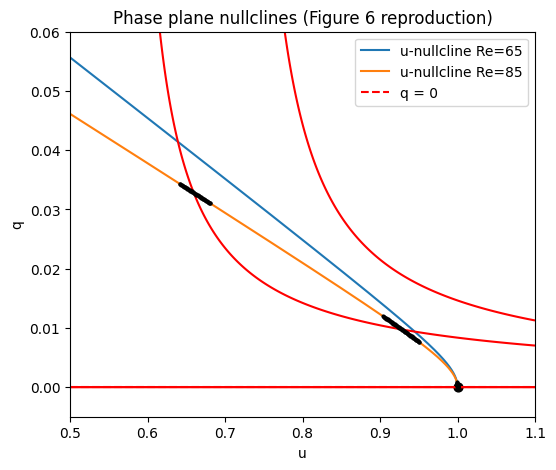

In [15]:
q_pos = np.linspace(0, 0.06, 800)
q_axis = np.linspace(-0.005, 0.06, 800)
u_vals = np.linspace(0.5, 1.1, 800)

plt.figure(figsize=(6,5))

for Re in [65, 85]:

    u_nc = u_nullcline(q_pos, Re)
    plt.plot(u_nc, q_pos, label=f'u-nullcline Re={Re}')

    U, Q = np.meshgrid(u_vals, q_axis)
    F = 0.5*beta*U*A(Q) - 2*alpha*Q - eps0(Q, Re)

    plt.contour(U, Q, F, levels=[0], colors='red')

    intersections = []

    for q in q_pos:

        u1 = u_nullcline(q, Re)

        if 0.5 < u1 < 1.1:

            f = lambda qq: q_equation(qq, u1, Re)

            if abs(f(q)) < 1e-4:
                intersections.append((u1, q))

    for (u_i, q_i) in intersections:
        plt.scatter(u_i, q_i, color='black', s=4, zorder=5)


plt.plot(u_vals, np.zeros_like(u_vals), 'r--', label='q = 0')
plt.scatter(1, 0, color='black', s=40)
plt.xlim(0.5, 1.1)
plt.ylim(-0.005, 0.06)
plt.xlabel("u")
plt.ylabel("q")
plt.title("Phase plane nullclines (Figure 6 reproduction)")
plt.legend()
plt.show()

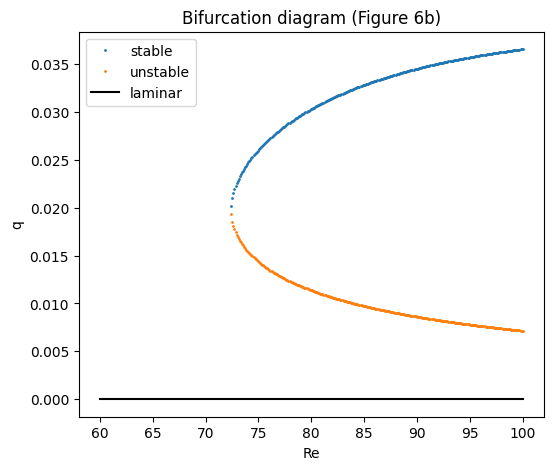

In [16]:
def steady_q_equation(q, Re):
    u = u_nullcline(q, Re)
    return 0.5*beta*u*A(q) - 2*alpha*q - eps0(q, Re)
def dA_dq(q):
    return a*q/np.sqrt(q**2 + eta**2)
Re_vals = np.linspace(60,100,400)

stable_Re = []
stable_q = []

unstable_Re = []
unstable_q = []

for Re in Re_vals:

    q_scan = np.linspace(0,0.08,400)
    f = steady_q_equation(q_scan, Re)

    for i in range(len(q_scan)-1):

        if f[i]*f[i+1] < 0:

            try:
                q = brentq(steady_q_equation,
                           q_scan[i],
                           q_scan[i+1],
                           args=(Re,))

                u = u_nullcline(q, Re)

                # Jacobian
                J11 = 0.5*beta*u*dA_dq(q) - 2*alpha - c/Re
                J12 = 0.5*beta*A(q)

                J21 = -beta*dA_dq(q)
                J22 = -alpha - beta**2/Re

                J = np.array([[J11,J12],[J21,J22]])

                eigvals = np.linalg.eigvals(J)

                if np.all(np.real(eigvals) < 0):
                    stable_Re.append(Re)
                    stable_q.append(q)
                else:
                    unstable_Re.append(Re)
                    unstable_q.append(q)

            except:
                pass


Re_lam = Re_vals
q_lam = np.zeros_like(Re_vals)
plt.figure(figsize=(6,5))
plt.plot(stable_Re, stable_q, '.', markersize=2, label='stable')
plt.plot(unstable_Re, unstable_q, '.', markersize=2, label='unstable')
plt.plot(Re_lam, q_lam, 'k', label='laminar')
plt.xlabel("Re")
plt.ylabel("q")
plt.title("Bifurcation diagram (Figure 6b)")
plt.legend()
plt.show()